In [218]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import pandas as pd
%config InlineBackend.figure_formats = ['svg']

In [406]:
def parse_criterion_mean_changes(file_name: str) -> [float]:
    result = []
    significant = []
    digit_pattern = r'[-+]?(?:[0-9]+.[0-9]+)'
    with open(file_name) as f:
        for line in f:
            line = line.replace("−", "-") # replacing strange Criterion minus sign, which is not actually minus
            matches = re.findall(f'change: \\[{digit_pattern}% ({digit_pattern})% {digit_pattern}%\\] \\(p = ({digit_pattern}) [<=>] 0.05\\)', line)
            if matches:
                diff = float(matches[0][0])
                p_value = float(matches[0][1])
                result.append(diff)
                # the same criteria is used in Tango
                significant.append(p_value < 0.05 and abs(diff) >= 0.005)
    return result, significant

def parse_tango_changes(file_name: str) -> [float]:
    result = []
    significant = []
    with open(file_name) as f:
        for line in f:
            matches = re.findall(r"([-+][0-9]+.[0-9]+)%(\*?)$", line)[0]
            result.append(float(matches[0]))
            significant.append(matches[1] == "*")
    return result, significant

In [452]:
experiment_path = "exp3"

tango, tango_significant = parse_tango_changes(f"{experiment_path}/tango.txt")
criterion, criterion_significant = parse_criterion_mean_changes(f"{experiment_path}/criterion.txt")
criterion_paired, criterion_paired_significant = parse_criterion_mean_changes(f"{experiment_path}/criterion-in-place.txt")

data = pd.DataFrame({
    'tango': tango,
    'criterion': criterion,
    'criterion_paired': criterion_paired,
})

significant = pd.DataFrame({
    'tango': tango_significant,
    'criterion': criterion_significant,
    'criterion_paired': criterion_paired_significant,
})

display(data.describe())

significant.mean()

,tango,criterion,criterion_paired
count,2964.000000,2964.000000,2964.000000
mean,0.020614,0.645125,0.226551
std,0.607804,4.491867,6.473912
min,-8.620000,-1.050500,-54.641000
25%,-0.140000,-0.072900,-0.138800
50%,0.000000,0.041700,0.004700
75%,0.150000,0.153250,0.131350
max,9.040000,76.331000,113.370000


tango               0.000337
criterion           0.074561
criterion_paired    0.091430
dtype: float64

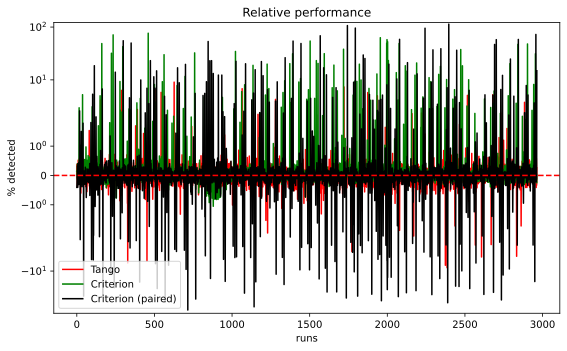

In [453]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(data.index, data['tango'], color='red', label="Tango")
ax.plot(data.index, data['criterion'], color='green', label="Criterion")
ax.plot(data.index, data['criterion_paired'], color='black', label="Criterion (paired)")

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

ax.set_yscale('symlog')

ax.set_title('Relative performance')
ax.set_xlabel('runs')
ax.set_ylabel('% detected')

ax.legend()

plt.tight_layout()
plt.show()

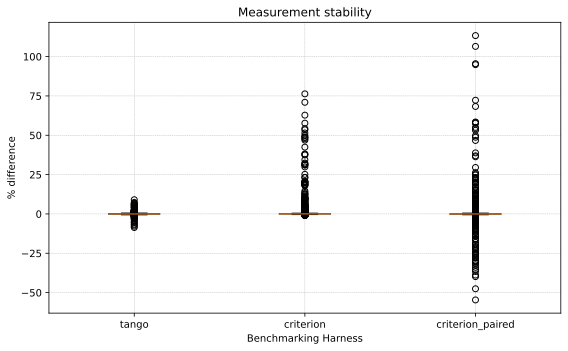

In [454]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot([data[col] for col in data.columns], tick_labels=data.columns, showfliers=True, whis=1.5)
#ax.set_yscale('symlog')

ax.set_title('Measurement stability')
ax.set_xlabel('Benchmarking Harness')
ax.set_ylabel('% difference')
ax.grid(linestyle='--', linewidth=0.4)

plt.tight_layout()
plt.show()

<Axes: >

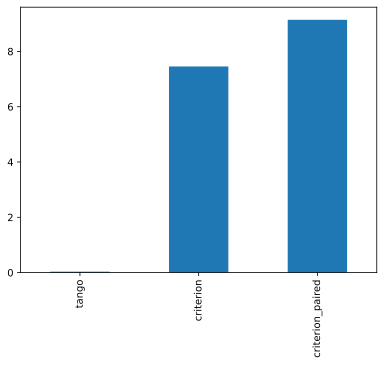

In [456]:
(significant.mean() * 100).plot(kind='bar')